# Flow Matching (using flow_matching package)

In [5]:
import time
import datetime
import torch
from torch import nn, Tensor
from torch.utils.data import TensorDataset, DataLoader, random_split

# flow_matching
from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper

# visualization
import matplotlib.pyplot as plt
import numpy as np

In [5]:
class Flow(nn.Module):
    def __init__(self, dim: int = 32, h: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, dim))
    
    def forward(self, t: Tensor, x_t: Tensor) -> Tensor:
        return self.net(torch.cat((t, x_t), -1))
    
    def step(self, x_t: Tensor, t_start: Tensor, t_end: Tensor) -> Tensor:
        t_start = t_start.view(1, 1).expand(x_t.shape[0], 1)
        
        return x_t + (t_end - t_start) * self(t=t_start + (t_end - t_start) / 2, x_t= x_t + self(x_t=x_t, t=t_start) * (t_end - t_start) / 2)

In [33]:
num_epochs = 50
batch_size = 4

attenu_latent = torch.load('attenu_latent.pt')
attenu_latent.shape

attenu_latent_dataset = TensorDataset(attenu_latent, attenu_latent)

train_size = (int(0.7 * len(attenu_latent)) // 4) * 4
val_size = int((len(attenu_latent) - train_size)/2)
test_size = int(len(attenu_latent) - train_size - val_size)

generator = torch.Generator().manual_seed(42)
attenu_latent_train_dataset, attenu_latent_val_dataset, attenu_latent_test_dataset = random_split(attenu_latent_dataset, [train_size, val_size, test_size], generator=generator)

attenu_latent_train_dataloader = DataLoader(attenu_latent_train_dataset, batch_size = batch_size, shuffle = 1)
attenu_latent_val_dataloader = DataLoader(attenu_latent_val_dataset, batch_size = batch_size, shuffle = 1)
attenu_latent_test_dataloader = DataLoader(attenu_latent_test_dataset, batch_size = batch_size, shuffle = 1)

In [34]:
attenu_latent_train_dataset[:][0].shape

torch.Size([144, 32])

In [11]:
num_epochs = 50

flow = Flow()

optimizer = torch.optim.Adam(flow.parameters(), 1e-2)
loss_fn = nn.MSELoss()

epoch_loss = []
epoch_loss_val = []

for epoch in range(num_epochs):
    start = torch.Event(enable_timing=True)
    end = torch.Event(enable_timing=True)

    start.record()

    flow.train()
    running_loss = 0.0
    running_loss_val = 0.0
    for train_batch, _ in attenu_latent_train_dataloader:
        x_1 = train_batch
        x_0 = torch.randn_like(x_1)
        t = torch.rand(len(x_1), 1)
        
        x_t = (1 - t) * x_0 + t * x_1
        dx_t = x_1 - x_0
        
        optimizer.zero_grad()
        loss = loss_fn(flow(t=t, x_t=x_t), dx_t)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * train_batch.size(0)

    for val_batch, _ in attenu_latent_val_dataloader:
        x_1 = val_batch
        x_0 = torch.randn_like(x_1)
        t = torch.rand(len(x_1), 1)
        
        x_t = (1 - t) * x_0 + t * x_1
        dx_t = x_1 - x_0

        loss = loss_fn(flow(t=t, x_t=x_t), dx_t)

        running_loss_val += loss.item() * val_batch.size(0)
    
    epoch_loss.append(running_loss / len(attenu_latent_train_dataloader.dataset))
    epoch_loss_val.append(running_loss_val / len(attenu_latent_val_dataloader.dataset))

    end.record()

    print(f"Epoch [{epoch + 1}/{num_epochs}], loss: {epoch_loss[epoch]:.4f}, validation loss: {epoch_loss_val[epoch]:.4f}, time elapsed = {start.elapsed_time(end)/1000:.2f} s")
    
    # if epoch > 1:
    #     if epoch_loss_val[-1] > epoch_loss_val[-2]:
    #         print("Validation loss increased, early stopping")
    #         break

    

Epoch [1/50], loss: 0.9922, validation loss: 0.8021, time elapsed = 0.02 s
Epoch [2/50], loss: 0.8166, validation loss: 0.7719, time elapsed = 0.01 s
Epoch [3/50], loss: 0.7438, validation loss: 0.6800, time elapsed = 0.01 s
Epoch [4/50], loss: 0.7346, validation loss: 0.7351, time elapsed = 0.01 s
Epoch [5/50], loss: 0.6776, validation loss: 0.6444, time elapsed = 0.01 s
Epoch [6/50], loss: 0.6984, validation loss: 0.6898, time elapsed = 0.01 s
Epoch [7/50], loss: 0.6458, validation loss: 0.6465, time elapsed = 0.01 s
Epoch [8/50], loss: 0.6574, validation loss: 0.6029, time elapsed = 0.01 s
Epoch [9/50], loss: 0.6454, validation loss: 0.6686, time elapsed = 0.01 s
Epoch [10/50], loss: 0.5573, validation loss: 0.5039, time elapsed = 0.01 s
Epoch [11/50], loss: 0.5286, validation loss: 0.5412, time elapsed = 0.01 s
Epoch [12/50], loss: 0.5366, validation loss: 0.5278, time elapsed = 0.01 s
Epoch [13/50], loss: 0.5664, validation loss: 0.6412, time elapsed = 0.01 s
Epoch [14/50], loss: 

# Continous Flow Matching

In [ ]:
# from flow_matching.solver import ODESolver
# from flow_matching.utils import ModelWrapper 

# class Flow(ModelWrapper):
#     def __init__(self, dim=2, h=64):
#         super().__init__(nn.Module)
#         self.net = torch.nn.Sequential(
#             torch.nn.Linear(dim + 1, h), torch.nn.ELU(), 
#             torch.nn.Linear(h, dim)) 
        
#     def forward(self, x, t):
#         t = t.view(-1, 1).expand(*x.shape[:-1], -1)
#         return self.net(torch.cat((t, x), -1))
        
        
# velocity_model = Flow() 
# # Optimize the model parameters s.t. model(x_t, t) = ut(Xt)
# # 
# x_0 = torch.randn(batch_size, 2) # Specify the initial condition

# solver = ODESolver(velocity_model=velocity_model) 
# num_steps = 100
# x_1 = solver.sample(x_init=x_0, method='midpoint', step_size=1.0 / num_steps)

## 2D Moon Example

In [40]:
import torch
from torch import nn, Tensor
from flow_matching.path import ProbPath
from flow_matching.path.path_sample import PathSample
from flow_matching.solver import ODESolver
from flow_matching.utils import ModelWrapper
from torch.utils.data import TensorDataset, DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt

import time
import datetime

class Flow(ModelWrapper):
    def __init__(self, dim=2, h=64):
        super().__init__(nn.Module)
        self.net = torch.nn.Sequential(
            torch.nn.Linear(dim + 1, h), torch.nn.ELU(), 
            torch.nn.Linear(h, dim)) 
        
    def forward(self, x, t):
        t = t.view(-1, 1).expand(*x.shape[:-1], -1)
        return self.net(torch.cat((t, x), -1))

In [ ]:
from sklearn.datasets import make_moons
attenu_latent = Tensor(make_moons(5000, noise=0.1)[0])
attenu_latent_dataset = TensorDataset(attenu_latent, attenu_latent)

velocity_model = Flow(dim = attenu_latent.shape[1])
path = AffineProbPath(scheduler=CondOTScheduler())
optimizer = torch.optim.Adam(velocity_model.parameters())

train_size = (int(0.7 * len(attenu_latent)) // 4) * 4
val_size = int((len(attenu_latent) - train_size)/2)
test_size = int(len(attenu_latent) - train_size - val_size)
batch_size = 500

generator = torch.Generator().manual_seed(42)
attenu_latent_train_dataset, attenu_latent_val_dataset, attenu_latent_test_dataset = random_split(attenu_latent_dataset, [train_size, val_size, test_size], generator=generator)

attenu_latent_train_dataloader = DataLoader(attenu_latent_train_dataset, batch_size = batch_size, shuffle = 1)
attenu_latent_val_dataloader = DataLoader(attenu_latent_val_dataset, batch_size = batch_size, shuffle = 1)
attenu_latent_test_dataloader = DataLoader(attenu_latent_test_dataset, batch_size = batch_size, shuffle = 1)

# training arguments
hidden_dim = 128

start_time = time.time()

steps = 0
losses = []
epoch = 3000
print_every = 100

for i in range(epoch):
    for _, x_1 in attenu_latent_train_dataloader:
        # Samples from π0,1 of shape [batch_size, *data_dim]
        x_0 = torch.randn_like(x_1)
        t = torch.rand(x_0.shape[0])
        # Randomize time t ∼ U [0, 1]
        # 
        sample: PathSample = path.sample(t=t, x_0=x_0, x_1=x_1)
        x_t = sample.x_t
        dx_t = sample.dx_t # dX_t is ψ ̇t(X0|X1).
        
        # If D is the Euclidean distance, the CFM objective corresponds to the mean-squared error
        cfm_loss = torch.pow(velocity_model(x_t, t) - dx_t, 2).mean() # Monte Carlo estimate
        optimizer.zero_grad()
        cfm_loss.backward()
        optimizer.step()

        losses.append(cfm_loss.item())

    # log loss
    if (i+1) % print_every == 0:
        elapsed = time.time() - start_time
        print('| Epoch {:6d} | {:5.2f} ms/step | loss {:8.3f} ' 
            .format(i+1, elapsed*1000/print_every, losses[-1])) 
        start_time = time.time()

| Epoch    100 |  6.90 ms/step | loss    1.148 
| Epoch    200 |  6.95 ms/step | loss    1.098 
| Epoch    300 |  6.76 ms/step | loss    1.088 
| Epoch    400 |  6.88 ms/step | loss    1.112 
| Epoch    500 |  7.03 ms/step | loss    1.065 
| Epoch    600 |  6.76 ms/step | loss    1.090 
| Epoch    700 |  6.84 ms/step | loss    1.073 
| Epoch    800 |  6.78 ms/step | loss    1.040 
| Epoch    900 |  6.81 ms/step | loss    1.068 
| Epoch   1000 |  6.44 ms/step | loss    1.055 
| Epoch   1100 |  7.11 ms/step | loss    1.030 
| Epoch   1200 |  6.91 ms/step | loss    1.067 
| Epoch   1300 |  7.21 ms/step | loss    1.001 
| Epoch   1400 |  6.47 ms/step | loss    1.080 
| Epoch   1500 |  6.78 ms/step | loss    1.068 
| Epoch   1600 |  6.82 ms/step | loss    0.955 
| Epoch   1700 |  6.80 ms/step | loss    1.089 
| Epoch   1800 |  6.44 ms/step | loss    1.062 
| Epoch   1900 |  6.77 ms/step | loss    1.021 
| Epoch   2000 |  6.77 ms/step | loss    0.980 
| Epoch   2100 |  6.80 ms/step | loss   

In [282]:
#x_0 = torch.randn(x_1.shape)
solver = ODESolver(velocity_model=velocity_model)

sample_size = 1000
x_0 = torch.randn(sample_size, attenu_latent.shape[1])
x_1 = solver.sample(x_0, step_size = 0.01)

x_0.requires_grad = True
x_1 = solver.sample(x_0, step_size = 0.01)
x_1.requires_grad = True

from torch.distributions import Independent, Normal
gaussian_log_density = Independent(Normal(torch.zeros(attenu_latent_train_dataset[0][0].shape[0]), torch.ones(attenu_latent_train_dataset[0][0].shape[0])), 1).log_prob

log_p1 = torch.tensor([])
log_p1.requires_grad = True

x_0_verify, log_p1 = solver.compute_likelihood(x_1=x_1,
                                        method='dopri5',
                                        step_size= 0.01,
                                        log_p0= gaussian_log_density,
                                        enable_grad = True, exact_divergence = True
                                        )

# torch.autograd.grad(log_p1[0], y_init[0][0, :])
# torch.autograd.grad(x_1[0, 0], x_0[0],retain_graph=True)

grad = torch.zeros(x_1.shape)
for i in range(x_1.shape[0]):
    grad[i, :] = torch.autograd.grad(log_p1[i], x_1, retain_graph= True)[0][i, :]

# log_p1.backward()
# grad_1 = x_1.grad.detach().numpy()

# grad = torch.zeros(x_1.shape)
# for i in range(log_p1.shape[0]):
#     

/Users/leo/miniconda3/envs/venv_pytorch/lib/python3.14/site-packages/torchdiffeq/_impl/misc.py:15: UserWarning: Dopri5Solver: Unexpected arguments {'step_size': 0.01}
  warnings.warn('{}: Unexpected arguments {}'.format(solver.__class__.__name__, unused_kwargs))


Text(0.5, 0.98, 'autograd')

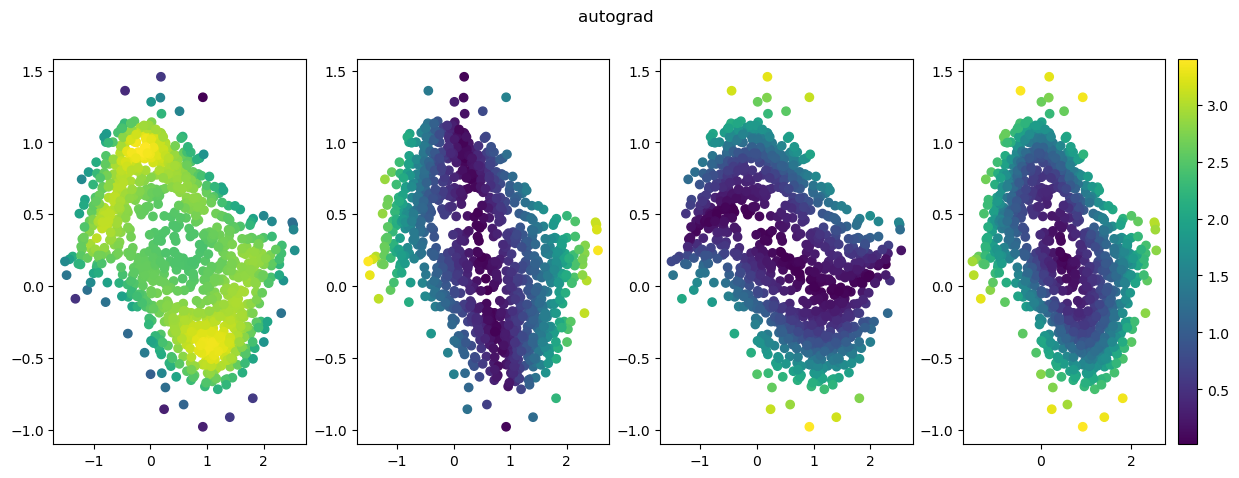

In [283]:
figs, axs = plt.subplots(1,4, figsize = (15, 5))
axs[0].scatter(x_1[:, 0].detach().numpy(), x_1[:, 1].detach().numpy(), c = log_p1.detach().numpy())
axs[1].scatter(x_1[:, 0].detach().numpy(), x_1[:, 1].detach().numpy(), c = torch.abs(grad[:, 0]).detach().numpy())
axs[2].scatter(x_1[:, 0].detach().numpy(), x_1[:, 1].detach().numpy(), c = torch.abs(grad[:, 1]).detach().numpy())
im3 = axs[3].scatter(x_1[:, 0].detach().numpy(), x_1[:, 1].detach().numpy(), c = torch.sqrt(grad[:, 0] ** 2 + grad[:, 1] ** 2).detach().numpy())
plt.colorbar(im3)
figs.suptitle("autograd")

In [337]:
# central diff
grad_fd = torch.zeros(x_1.shape)

#step_sizes = float(10) ** (torch.arange(-7, -1, 0.1))
#diff_central = []
#diff_logp1_central = []

step = 1e-5

for i in range(grad_fd.shape[0]):
    for j in range(grad_fd.shape[1]):

        x_1_perturb_positive = x_1.clone().detach()

        x_1_perturb_positive = x_1_perturb_positive[i:i+1, :]
        x_1_perturb_positive[0,j] += step

        x_1_perturb_negative = x_1.clone().detach()
        x_1_perturb_negative = x_1_perturb_negative[i:i+1, :]
        x_1_perturb_negative[0,j] -= step

        _, log_p1_sample_perturb_postive = solver.compute_likelihood(x_1=x_1_perturb_positive,
                            method='midpoint',
                            step_size= 1e-2,
                            log_p0= gaussian_log_density,
                            enable_grad = True, exact_divergence = True
                            )

        _, log_p1_sample_perturb_negative = solver.compute_likelihood(x_1=x_1_perturb_negative,
                            method='midpoint',
                            step_size= 1e-2,
                            log_p0= gaussian_log_density,
                            enable_grad = True, exact_divergence = True
                            )

        diff_central = ((log_p1_sample_perturb_postive - log_p1_sample_perturb_negative)/(step * 2))
        #diff_central = ((log_p1_sample_perturb_postive - log_p1[i])/(step))
        grad_fd[i,j] = diff_central


Text(0.5, 0.98, 'FD')

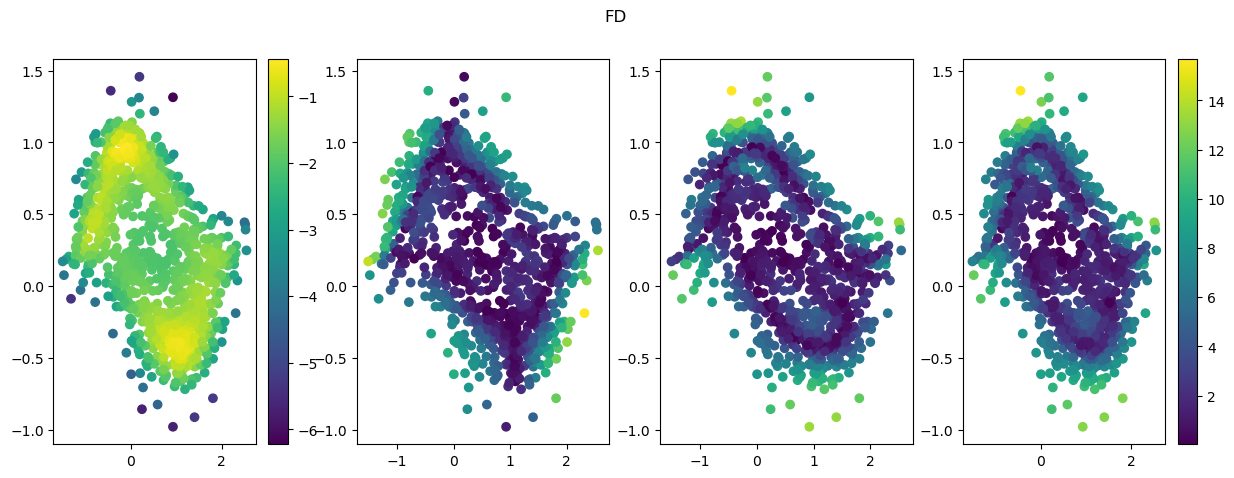

In [338]:
figs, axs = plt.subplots(1,4, figsize = (15, 5))
im0 = axs[0].scatter(x_1[:, 0].detach().numpy(), x_1[:, 1].detach().numpy(), c = log_p1.detach().numpy())
axs[1].scatter(x_1[:, 0].detach().numpy(), x_1[:, 1].detach().numpy(), c = torch.abs(grad_fd[:, 0]).detach().numpy())
axs[2].scatter(x_1[:, 0].detach().numpy(), x_1[:, 1].detach().numpy(), c = torch.abs(grad_fd[:, 1]).detach().numpy())
im3 = axs[3].scatter(x_1[:, 0].detach().numpy(), x_1[:, 1].detach().numpy(), c = torch.sqrt(grad_fd[:, 0] ** 2 + grad_fd[:, 1] ** 2).detach().numpy())
plt.colorbar(im0)
plt.colorbar(im3)
figs.suptitle("FD")

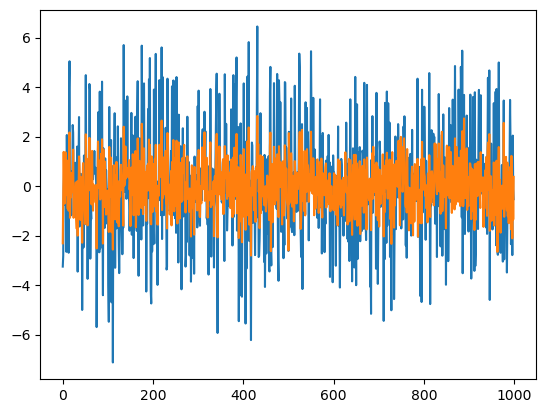

In [339]:
plt.plot(grad_fd[:, 0].detach().numpy())
plt.plot(grad[:, 0].detach().numpy())

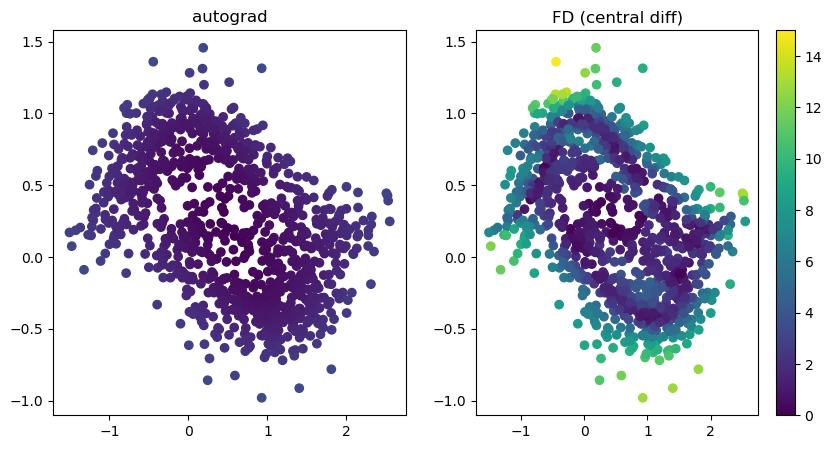

In [341]:
figs, axs = plt.subplots(1,2,figsize = (10, 5))

vmin = 0
vmax = 15

im0 = axs[0].scatter(x_1[:, 0].detach().numpy(), x_1[:, 1].detach().numpy(), 
                     c = torch.sqrt(grad[:, 0] ** 2 + grad[:, 1] ** 2).detach().numpy(),
                     vmin = vmin, vmax = vmax)

im1 = axs[1].scatter(x_1[:, 0].detach().numpy(), x_1[:, 1].detach().numpy(), 
                     c = torch.sqrt(grad_fd[:, 0] ** 2 + grad_fd[:, 1] ** 2).detach().numpy(),
                     vmin = vmin, vmax = vmax)

axs[0].set_title("autograd")
axs[1].set_title("FD (central diff)")

plt.colorbar(im1)


## Autograd & FD Testing

In [123]:
import torch
from torch import nn, Tensor
from flow_matching.path import ProbPath
from flow_matching.utils import ModelWrapper
from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import Solver, ODESolver
from torch.utils.data import TensorDataset, DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt


import time
import datetime

class Flow(ModelWrapper):
    def __init__(self, dim=2, h=64):
        super().__init__(nn.Module)
        self.net = torch.nn.Sequential(
            torch.nn.Linear(dim + 1, h), torch.nn.ELU(), 
            torch.nn.Linear(h, dim)) 
        
    def forward(self, x, t):
        t = t.view(-1, 1).expand(*x.shape[:-1], -1)
        return self.net(torch.cat((t, x), -1))

In [299]:
import sympy as sp
x, y = sp.symbols('x y')

A = 1
std_x = 1
std_y = 15
x0 = 1
y0 = 3
two_d_gaussian = A * sp.exp(-((((x - x0) ** 2))/(2 * (std_x ** 2)) + (((y - y0) ** 2))/(2 * (std_y ** 2)))) 
two_d_gaussian = two_d_gaussian / sp.integrate(two_d_gaussian, (x, -sp.oo, sp.oo), (y, -sp.oo, sp.oo))
two_d_gaussian_dx = sp.diff(two_d_gaussian, x)
two_d_gaussian_dy = sp.diff(two_d_gaussian, y)

two_d_gaussian = sp.lambdify((x,y), two_d_gaussian)
two_d_gaussian_dx = sp.lambdify((x,y), two_d_gaussian_dx)
two_d_gaussian_dy = sp.lambdify((x,y), two_d_gaussian_dy)

(np.float64(-2.8081530809402464),
 np.float64(4.99377863407135),
 np.float64(-10.219348812103272),
 np.float64(18.41911115646362))

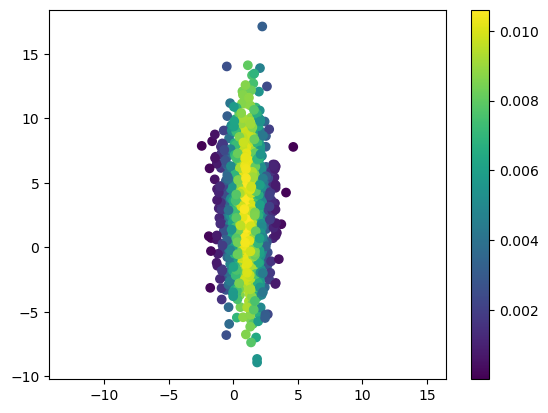

In [300]:
from scipy.stats import norm

x_1 = np.random.multivariate_normal((x0, y0), np.array([[std_x, 0], [0, std_y]]), 1000).astype('float32')


gaussian_p = two_d_gaussian(x_1[:,0], x_1[:,1])

im1 = plt.scatter(x_1[:,0], x_1[:,1], c = gaussian_p)
plt.colorbar(im1)
plt.axis('equal')

In [259]:
from sklearn.datasets import make_moons
attenu_latent = torch.tensor(x_1)
attenu_latent_dataset = TensorDataset(attenu_latent, attenu_latent)

velocity_model = Flow(dim = attenu_latent.shape[1])
path = AffineProbPath(scheduler=CondOTScheduler())
optimizer = torch.optim.Adam(velocity_model.parameters())

train_size = (int(0.7 * len(attenu_latent)) // 4) * 4
val_size = int((len(attenu_latent) - train_size)/2)
test_size = int(len(attenu_latent) - train_size - val_size)
batch_size = 500

generator = torch.Generator().manual_seed(42)
attenu_latent_train_dataset, attenu_latent_val_dataset, attenu_latent_test_dataset = random_split(attenu_latent_dataset, [train_size, val_size, test_size], generator=generator)

attenu_latent_train_dataloader = DataLoader(attenu_latent_train_dataset, batch_size = batch_size, shuffle = 1)
attenu_latent_val_dataloader = DataLoader(attenu_latent_val_dataset, batch_size = batch_size, shuffle = 1)
attenu_latent_test_dataloader = DataLoader(attenu_latent_test_dataset, batch_size = batch_size, shuffle = 1)

# training arguments
hidden_dim = 128

start_time = time.time()

steps = 0
losses = []
epoch = 3000
print_every = 100

for i in range(epoch):
    for _, x_1 in attenu_latent_train_dataloader:
        # Samples from π0,1 of shape [batch_size, *data_dim]
        x_0 = torch.randn_like(x_1)
        t = torch.rand(x_0.shape[0])
        # Randomize time t ∼ U [0, 1]
        # 
        sample: PathSample = path.sample(t=t, x_0=x_0, x_1=x_1)
        x_t = sample.x_t
        dx_t = sample.dx_t # dX_t is ψ ̇t(X0|X1).
        
        # If D is the Euclidean distance, the CFM objective corresponds to the mean-squared error
        cfm_loss = torch.pow(velocity_model(x_t, t) - dx_t, 2).mean() # Monte Carlo estimate
        optimizer.zero_grad()
        cfm_loss.backward()
        optimizer.step()

        losses.append(cfm_loss.item())

    # log loss
    if (i+1) % print_every == 0:
        elapsed = time.time() - start_time
        print('| Epoch {:6d} | {:5.2f} ms/step | loss {:8.3f} ' 
            .format(i+1, elapsed*1000/print_every, losses[-1])) 
        start_time = time.time()

/var/folders/zz/9d0y_vp944zcnd6w_nl_3x6r0000gn/T/ipykernel_46585/2023240302.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  attenu_latent = torch.tensor(x_1)


| Epoch    100 |  1.63 ms/step | loss    4.202 
| Epoch    200 |  1.27 ms/step | loss    3.783 
| Epoch    300 |  1.27 ms/step | loss    3.270 
| Epoch    400 |  1.25 ms/step | loss    3.721 
| Epoch    500 |  1.29 ms/step | loss    3.475 
| Epoch    600 |  1.95 ms/step | loss    3.503 
| Epoch    700 |  1.37 ms/step | loss    3.243 
| Epoch    800 |  1.27 ms/step | loss    3.049 
| Epoch    900 |  1.27 ms/step | loss    3.999 
| Epoch   1000 |  1.27 ms/step | loss    3.571 
| Epoch   1100 |  1.97 ms/step | loss    3.444 
| Epoch   1200 |  1.26 ms/step | loss    3.843 
| Epoch   1300 |  1.27 ms/step | loss    3.635 
| Epoch   1400 |  1.27 ms/step | loss    3.045 
| Epoch   1500 |  1.27 ms/step | loss    3.010 
| Epoch   1600 |  1.96 ms/step | loss    3.244 
| Epoch   1700 |  1.27 ms/step | loss    3.606 
| Epoch   1800 |  1.26 ms/step | loss    3.529 
| Epoch   1900 |  1.27 ms/step | loss    3.205 
| Epoch   2000 |  1.30 ms/step | loss    2.949 
| Epoch   2100 |  2.08 ms/step | loss   

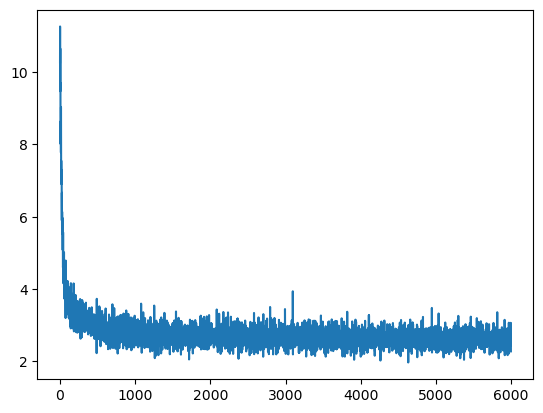

In [148]:
plt.plot(losses)

In [302]:
#x_0 = torch.randn(x_1.shape)
solver = ODESolver(velocity_model=velocity_model)

sample_size = 1000
x_0 = torch.randn(sample_size, attenu_latent.shape[1])
x_1 = solver.sample(x_0, step_size = 0.01)

x_1.requires_grad = True

from torch.distributions import Independent, Normal
gaussian_log_density = Independent(Normal(torch.zeros(attenu_latent_train_dataset[0][0].shape[0]), torch.ones(attenu_latent_train_dataset[0][0].shape[0])), 1).log_prob

log_p1 = torch.tensor([])
log_p1.requires_grad = True

x_0_verify, log_p1 = solver.compute_likelihood(x_1=x_1,
                                        method='midpoint',
                                        step_size= 0.01,
                                        log_p0= gaussian_log_density,
                                        enable_grad = True, exact_divergence = True
                                        )

# torch.autograd.grad(log_p1[0], y_init[0][0, :])
# torch.autograd.grad(x_1[0, 0], x_0[0],retain_graph=True)

normalization_c = torch.sum(torch.e ** log_p1)

grad = torch.zeros(x_1.shape)
for i in range(x_1.shape[0]):
    grad[i, :] = torch.autograd.grad((torch.e ** log_p1[i])/normalization_c, x_1, retain_graph= True)[0][i, :]

grad = grad.detach().numpy()

# log_p1.backward()
# grad_1 = x_1.grad.detach().numpy()

# grad = torch.zeros(x_1.shape)
# for i in range(log_p1.shape[0]):
#     

(np.float64(-1.705846256017685),
 np.float64(4.810487812757492),
 np.float64(-4.717577350139618),
 np.float64(12.406028401851653))

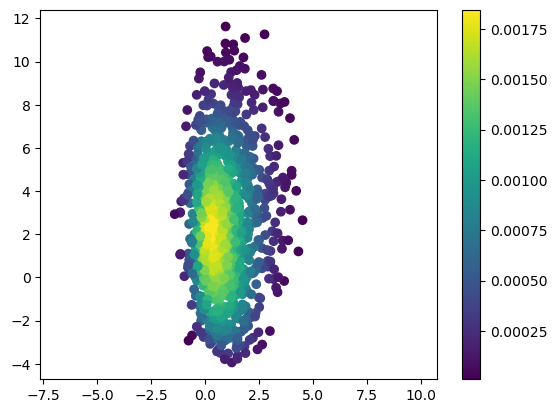

In [303]:
im1 = plt.scatter(x_1[:, 0].detach().numpy(), x_1[:, 1].detach().numpy(), c = ((np.e ** log_p1 / normalization_c).detach().numpy()))
plt.colorbar(im1)
plt.axis('equal')

In [304]:
# central diff
grad_fd = torch.zeros(x_1.shape)

#step_sizes = float(10) ** (torch.arange(-7, -1, 0.1))
#diff_central = []
#diff_logp1_central = []

step = 1e-5

for i in range(grad_fd.shape[0]):
    for j in range(grad_fd.shape[1]):

        x_1_perturb_positive = x_1.clone().detach()

        x_1_perturb_positive = x_1_perturb_positive[i:i+1, :]
        x_1_perturb_positive[0,j] += step

        x_1_perturb_negative = x_1.clone().detach()
        x_1_perturb_negative = x_1_perturb_negative[i:i+1, :]
        x_1_perturb_negative[0,j] -= step

        _, log_p1_sample_perturb_positive = solver.compute_likelihood(x_1=x_1_perturb_positive,
                            method='midpoint',
                            step_size= 1e-2,
                            log_p0= gaussian_log_density,
                            enable_grad = True, exact_divergence = True
                            )

        _, log_p1_sample_perturb_negative = solver.compute_likelihood(x_1=x_1_perturb_negative,
                            method='midpoint',
                            step_size= 1e-2,
                            log_p0= gaussian_log_density,
                            enable_grad = True, exact_divergence = True
                            )

        log_p1_sample_perturb_positive = (np.e ** log_p1_sample_perturb_positive) / normalization_c
        log_p1_sample_perturb_negative = (np.e ** log_p1_sample_perturb_negative) / normalization_c

        diff_central = ((log_p1_sample_perturb_positive - log_p1_sample_perturb_negative)/(step * 2))
        #diff_central = ((log_p1_sample_perturb_positive - log_p1[i])/(step))
        grad_fd[i,j] = diff_central
grad_fd = grad_fd.detach().numpy()

(np.float64(-1.705846256017685),
 np.float64(4.810487812757492),
 np.float64(-4.717577350139618),
 np.float64(12.406028401851653))

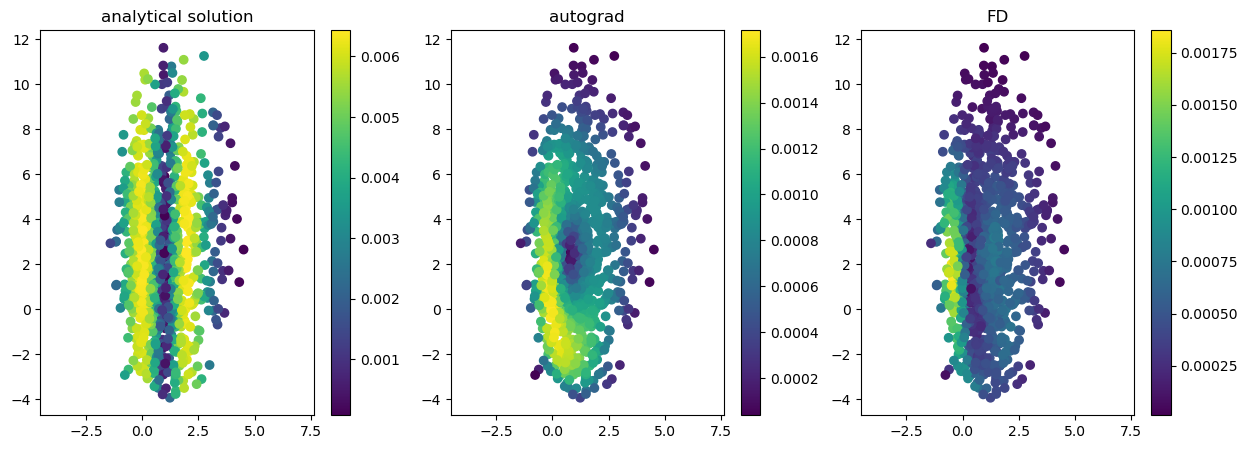

In [310]:
grad_analytical = np.sqrt(two_d_gaussian_dx(x_1[:, 0].detach().numpy(), x_1[:, 1].detach().numpy()) ** 2 + two_d_gaussian_dy(x_1[:, 0].detach().numpy(), x_1[:, 1].detach().numpy()) ** 2)

figs, axs = plt.subplots(1,3,figsize = (15, 5))
im0 = axs[0].scatter(x_1[:, 0].detach().numpy(), x_1[:, 1].detach().numpy(), c = grad_analytical)
plt.colorbar(im0)
axs[0].set_title("analytical solution")
axs[0].axis('equal')

im1 = axs[1].scatter(x_1[:, 0].detach().numpy(), x_1[:, 1].detach().numpy(), c = np.sqrt(grad[:, 0] ** 2 + grad[:, 1] ** 2))
plt.colorbar(im1)
axs[1].set_title("autograd")
axs[1].axis('equal')

im2 = axs[2].scatter(x_1[:, 0].detach().numpy(), x_1[:, 1].detach().numpy(), c = np.sqrt(grad_fd[:, 0] ** 2 + grad_fd[:, 1] ** 2))
plt.colorbar(im2)
axs[2].set_title("FD")
axs[2].axis('equal')

(np.float64(-1.705846256017685),
 np.float64(4.810487812757492),
 np.float64(-4.717577350139618),
 np.float64(12.406028401851653))

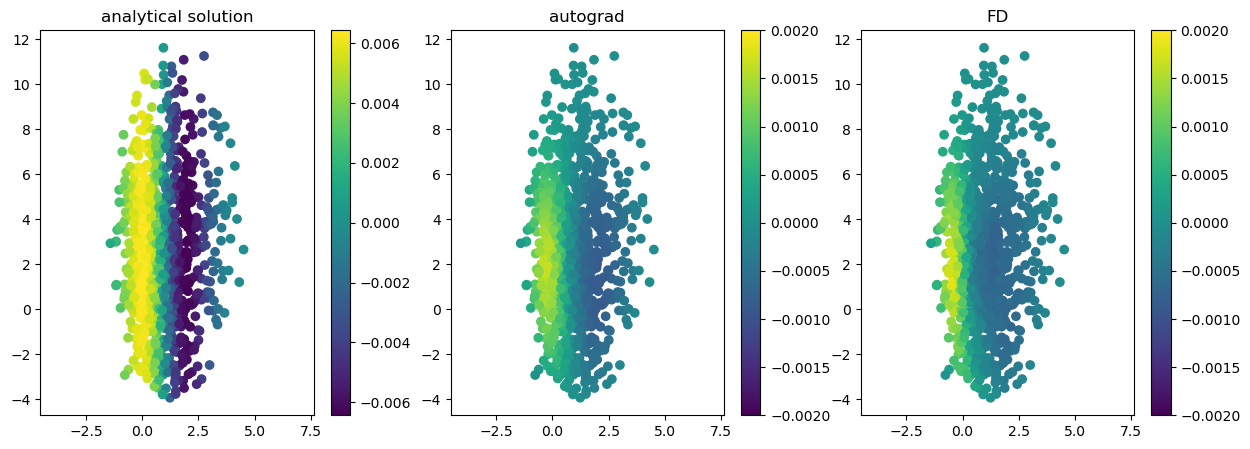

In [315]:
grad_analytical = np.sqrt(two_d_gaussian_dx(x_1[:, 0].detach().numpy(), x_1[:, 1].detach().numpy()) ** 2 + two_d_gaussian_dy(x_1[:, 0].detach().numpy(), x_1[:, 1].detach().numpy()) ** 2)

vmin = -0.002
vmax = 0.002

figs, axs = plt.subplots(1,3,figsize = (15, 5))
im0 = axs[0].scatter(x_1[:, 0].detach().numpy(), x_1[:, 1].detach().numpy(), c = two_d_gaussian_dx(x_1[:, 0].detach().numpy(), x_1[:, 1].detach().numpy()))
plt.colorbar(im0)
axs[0].set_title("analytical solution")
axs[0].axis('equal')

im1 = axs[1].scatter(x_1[:, 0].detach().numpy(), x_1[:, 1].detach().numpy(), c = grad[:, 0], vmin = vmin, vmax = vmax)
plt.colorbar(im1)
axs[1].set_title("autograd")
axs[1].axis('equal')

im2 = axs[2].scatter(x_1[:, 0].detach().numpy(), x_1[:, 1].detach().numpy(), c = grad_fd[:, 0], vmin = vmin, vmax = vmax)
plt.colorbar(im2)
axs[2].set_title("FD")
axs[2].axis('equal')

## With Attenuation Rate (Latent)

In [128]:
import time
import datetime
import torch
from torch import nn, Tensor
from torch.utils.data import TensorDataset, DataLoader, random_split

# visualization
import matplotlib.pyplot as plt
import numpy as np

import torch
from flow_matching.path import ProbPath
from flow_matching.path import AffineProbPath
from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.solver import Solver, ODESolver
#from ode_solver_modified import Solver, ODESolver
from flow_matching.utils import ModelWrapper 


class Flow(ModelWrapper):
    def __init__(self, dim=2, h=64):
        super().__init__(nn.Module)
        self.net = torch.nn.Sequential(
            torch.nn.Linear(dim + 1, h), torch.nn.ELU(), 
            torch.nn.Linear(h, dim)) 
        
    def forward(self, x, t):
        t = t.view(-1, 1).expand(*x.shape[:-1], -1)
        return self.net(torch.cat((t, x), -1))
          


In [22]:
import joblib
attenu_pca = joblib.load('../testing/attenu_pca2026-06-12 15:13:52.857122.pkl')

batch_size = 4

attenu_fromEm_train_dataset = torch.load('../testing/attenu_fromEm_train_dataset.pt', weights_only = False)
attenu_fromEm_val_dataset = torch.load('../testing/attenu_fromEm_val_dataset.pt', weights_only = False)
attenu_fromEm_test_dataset = torch.load('../testing/attenu_fromEm_test_dataset.pt', weights_only = False)

attenu_latent_train_tensor = torch.tensor(attenu_pca.transform(attenu_fromEm_train_dataset[:][0].detach().numpy().reshape((attenu_fromEm_train_dataset[:][0].shape[0], -1)))).float()
attenu_latent_val_tensor = torch.tensor(attenu_pca.transform(attenu_fromEm_val_dataset[:][0].detach().numpy().reshape((attenu_fromEm_val_dataset[:][0].shape[0], -1)))).float()
attenu_latent_test_tensor = torch.tensor(attenu_pca.transform(attenu_fromEm_test_dataset[:][0].detach().numpy().reshape((attenu_fromEm_test_dataset[:][0].shape[0], -1)))).float()

attenu_latent_train_dataset = TensorDataset(attenu_latent_train_tensor, attenu_latent_train_tensor)
attenu_latent_val_dataset = TensorDataset(attenu_latent_val_tensor, attenu_latent_val_tensor)
attenu_latent_test_dataset = TensorDataset(attenu_latent_test_tensor, attenu_latent_test_tensor)

attenu_latent_train_dataloader = DataLoader(attenu_latent_train_dataset, batch_size = batch_size, shuffle = 1)
attenu_latent_val_dataloader = DataLoader(attenu_latent_val_dataset, batch_size = batch_size, shuffle = 1)
attenu_latent_test_dataloader = DataLoader(attenu_latent_test_dataset, batch_size = batch_size, shuffle = 1)

#### Training

In [24]:
hidden_dim = 128
velocity_model = Flow(dim = attenu_latent_train_dataset[0][0].shape[0], h = hidden_dim)
path = AffineProbPath(scheduler=CondOTScheduler())
optimizer = torch.optim.Adam(velocity_model.parameters(), lr = 1e-4)

start_time = time.time()

steps = 0
losses = []
epoch = 30000
print_every = 100

try:
    for i in range(epoch):
        for _, x_1 in attenu_latent_train_dataloader:
            # Samples from π0,1 of shape [batch_size, *data_dim]
            x_0 = torch.randn_like(x_1)
            t = torch.rand(x_0.shape[0])
            # Randomize time t ∼ U [0, 1]
            # 
            sample: PathSample = path.sample(t=t, x_0=x_0, x_1=x_1)
            x_t = sample.x_t
            dx_t = sample.dx_t # dX_t is ψ ̇t(X0|X1).
            
            # If D is the Euclidean distance, the CFM objective corresponds to the mean-squared error
            cfm_loss = torch.pow(velocity_model(x = x_t, t = t) - dx_t, 2).mean() # Monte Carlo estimate
            optimizer.zero_grad()
            cfm_loss.backward()
            optimizer.step()

            losses.append(cfm_loss.item())

        # log loss
        if (i+1) % print_every == 0:
            elapsed = time.time() - start_time
            print('| Epoch {:6d} | {:5.2f} ms/step | loss {:8.3f} ' 
                .format(i+1, elapsed*1000/print_every, losses[-1])) 
            start_time = time.time()

    torch.save(velocity_model.state_dict(), f'velocity_model{datetime.datetime.now()}.pth')

except KeyboardInterrupt:
    torch.save(velocity_model.state_dict(), f'velocity_model{datetime.datetime.now()}.pth')

| Epoch    100 |  7.20 ms/step | loss    9.699 
| Epoch    200 |  7.16 ms/step | loss    3.021 
| Epoch    300 |  7.24 ms/step | loss    9.700 


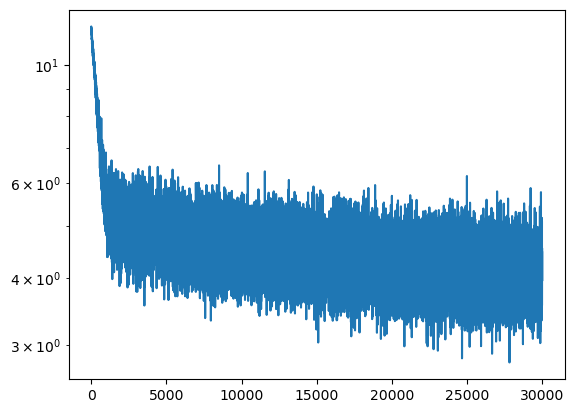

In [ ]:
plt.plot(losses)
plt.gca().set_yscale('log')

#### Inference

In [214]:
sample_size = 1
x_0 = torch.randn(sample_size, attenu_latent_train_dataset[0][0].shape[0], requires_grad = True)

In [227]:
%load_ext autoreload
%autoreload 2

#from ode_solver_modified import Solver, ODESolver
from flow_matching.solver import Solver, ODESolver

#x_0 = torch.randn(x_1.shape)
hidden_dim = 128
velocity_model = Flow(dim = attenu_latent_train_dataset[0][0].shape[0], h = hidden_dim)
velocity_model.load_state_dict(torch.load('../testing/velocity_model2026-06-12 15:38:01.965518.pth', weights_only=True))

solver = ODESolver(velocity_model=velocity_model)



x_0.requires_grad = True
x_1 = solver.sample(x_0, step_size = 0.01)
x_1.requires_grad = True

from torch.distributions import Independent, Normal
gaussian_log_density = Independent(Normal(torch.zeros(attenu_latent_train_dataset[0][0].shape[0]), torch.ones(attenu_latent_train_dataset[0][0].shape[0])), 1).log_prob

log_p1 = torch.tensor([])
log_p1.requires_grad = True

x_0_verify, log_p1 = solver.compute_likelihood(x_1=x_1,
                                        method='dopri5',
                                        step_size= 0.01,
                                        log_p0= gaussian_log_density,
                                        enable_grad = True, exact_divergence = True
                                        )

# torch.autograd.grad(log_p1[0], y_init[0][0, :])
# torch.autograd.grad(x_1[0, 0], x_0[0],retain_graph=True)


grad = torch.autograd.grad(log_p1, x_1, retain_graph = True)

# log_p1.backward()
# grad_1 = x_1.grad.detach().numpy()

# grad = torch.zeros(x_1.shape)
# for i in range(log_p1.shape[0]):
#     

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/Users/leo/miniconda3/envs/venv_pytorch/lib/python3.14/site-packages/torchdiffeq/_impl/misc.py:15: UserWarning: Dopri5Solver: Unexpected arguments {'step_size': 0.01}
  warnings.warn('{}: Unexpected arguments {}'.format(solver.__class__.__name__, unused_kwargs))


In [228]:
grad[0].detach().numpy()

array([[ 0.51687634,  0.76021063, -0.23346886,  0.2954224 ,  0.4678766 ,
         0.3750161 ,  0.48012125,  0.27428448,  1.2015034 , -1.814282  ,
        -0.33434042, -0.35447145, -1.2922677 , -0.43141764,  0.23148568,
        -0.10337721,  1.7874542 , -0.3772174 ,  1.5024176 ,  0.2473132 ,
         2.0169325 , -0.7314238 , -0.85850877,  0.08093292,  0.42612568,
        -1.4050434 ,  0.52707225, -0.32805043, -1.4581232 ,  1.1232995 ,
         1.788514  ,  0.0533334 ]], dtype=float32)

In [226]:
grad_1

array([[ 0.52294916,  0.7657837 , -0.22977534,  0.28508273,  0.4733874 ,
         0.37975854,  0.4871029 ,  0.27769375,  1.2056592 , -1.8167026 ,
        -0.34014514, -0.34204382, -1.2949278 , -0.42035323,  0.23477265,
        -0.10777417,  1.7917523 , -0.3808389 ,  1.5050147 ,  0.24210194,
         2.0197525 , -0.7352062 , -0.850191  ,  0.07279931,  0.4142395 ,
        -1.4091284 ,  0.53252774, -0.3356433 , -1.4618287 ,  1.1272874 ,
         1.7905421 ,  0.04608133]], dtype=float32)

In [212]:
x_1.shape

torch.Size([300, 32])

In [ ]:
(float(10) ** (torch.arange(-8, -1, 1, dtype=torch.float64))).dtype

torch.float64

In [129]:
x_1_perturb.shape

torch.Size([32])

In [ ]:
grad_fd = torch.zeros(x_1.shape)

step_sizes = torch.cat((float(10) ** (torch.arange(-7, -1, 0.1)), -float(10) ** (torch.arange(-7, -1, 0.1))))
diff = []
diff_logp1 = []

for step in step_sizes:

    x_1_perturb = x_1.clone().detach()
    x_1_perturb = x_1_perturb[0:1, :]
    x_1_perturb[0,0] += step
    print(x_1_perturb - x_1[0:1, :])
    _, log_p1_sample_perturb = solver.compute_likelihood(x_1=x_1_perturb,
                            method='midpoint',
                            step_size= 0.01,
                            log_p0= gaussian_log_density,
                            enable_grad = True, exact_divergence = True
                            )

    diff.append(((log_p1_sample_perturb - log_p1[0])/step).detach().numpy())
    diff_logp1.append(log_p1_sample_perturb)

diff_logp1 = torch.cat(diff_logp1)

tensor([[1.1921e-07, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00]], grad_fn=<SubBackward0>)
tensor([[1.1921e-07, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00]], grad_fn=<SubBackward0>)
tensor([[1.1921e-07, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0

In [201]:
# central diff
grad_fd = torch.zeros(x_1.shape)

step_sizes = float(10) ** (torch.arange(-7, -1, 0.1))
diff_central = []
diff_logp1_central = []

for step in step_sizes:

    x_1_perturb_positive = x_1.clone().detach()
    x_1_perturb_positive = x_1_perturb_positive[0:1, :]
    x_1_perturb_positive[0,0] += step

    x_1_perturb_negative = x_1.clone().detach()
    x_1_perturb_negative = x_1_perturb_negative[0:1, :]
    x_1_perturb_negative[0,0] -= step

    _, log_p1_sample_perturb_postive = solver.compute_likelihood(x_1=x_1_perturb_positive,
                            method='midpoint',
                            step_size= 0.01,
                            log_p0= gaussian_log_density,
                            enable_grad = True, exact_divergence = True
                            )

    _, log_p1_sample_perturb_negative = solver.compute_likelihood(x_1=x_1_perturb_negative,
                            method='midpoint',
                            step_size= 0.01,
                            log_p0= gaussian_log_density,
                            enable_grad = True, exact_divergence = True
                            )
    
    diff_central.append(((log_p1_sample_perturb_postive - log_p1_sample_perturb_negative)/(step * 2)).detach().numpy())
    diff_logp1_central.append(log_p1_sample_perturb_postive - log_p1_sample_perturb_negative)

diff_logp1_central = torch.cat(diff_logp1_central)

In [172]:
grad

tensor([[ 0.2903, -1.3523, -0.9891,  ...,  0.3558, -0.4711, -0.2140],
        [-0.6616,  1.3851,  0.2952,  ..., -1.0479,  0.0820, -0.9078],
        [ 2.4776, -1.4177, -0.3535,  ...,  1.3833,  0.2707,  0.3446],
        ...,
        [ 2.0976,  0.1986, -0.0991,  ..., -0.1599,  0.3223,  1.1390],
        [ 0.2077, -0.2405, -1.2364,  ...,  0.7521,  1.2597, -0.1843],
        [-1.1754,  1.5374,  0.2276,  ...,  0.3679,  1.0952, -0.2410]])

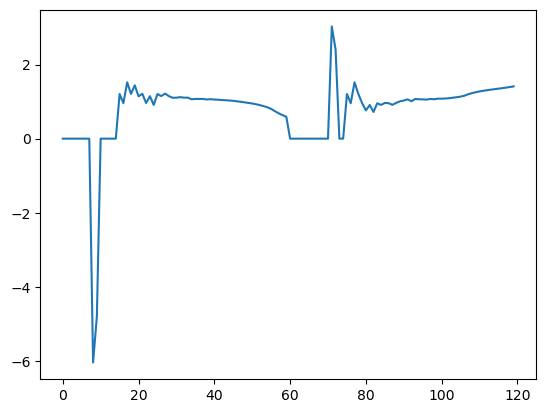

In [191]:
plt.plot((diff_logp1 - log_p1[0]).detach().numpy().flatten() / step_sizes.detach().numpy().flatten())

In [206]:
diff_logp1_central

tensor([ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00, -3.8147e-06, -3.8147e-06,
         0.0000e+00,  3.8147e-06,  3.8147e-06,  0.0000e+00,  0.0000e+00,
         7.6294e-06,  7.6294e-06,  1.5259e-05,  1.5259e-05,  1.9073e-05,
         1.9073e-05,  2.6703e-05,  2.6703e-05,  4.1962e-05,  4.5776e-05,
         6.8665e-05,  8.3923e-05,  1.0681e-04,  1.3351e-04,  1.6785e-04,
         2.1362e-04,  2.7466e-04,  3.3569e-04,  4.3488e-04,  5.3406e-04,
         6.7520e-04,  8.4686e-04,  1.0757e-03,  1.3390e-03,  1.7052e-03,
         2.1362e-03,  2.6894e-03,  3.3836e-03,  4.2801e-03,  5.3978e-03,
         6.8245e-03,  8.6327e-03,  1.1002e-02,  1.3947e-02,  1.7635e-02,
         2.2247e-02,  2.7992e-02,  3.5099e-02,  4.3945e-02,  5.4878e-02,
         6.8115e-02,  8.3790e-02,  1.0339e-01,  1.2808e-01,  1.5906e-01])

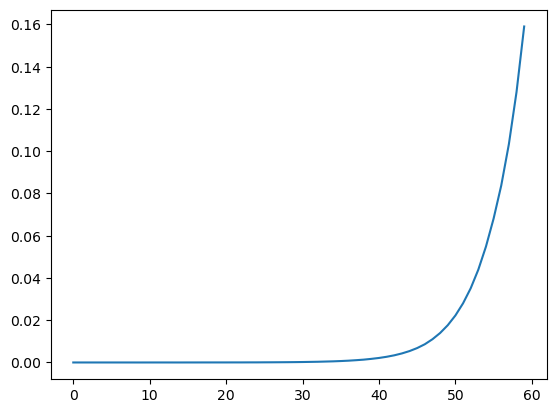

In [208]:
plt.plot((diff_logp1_central).detach().numpy())

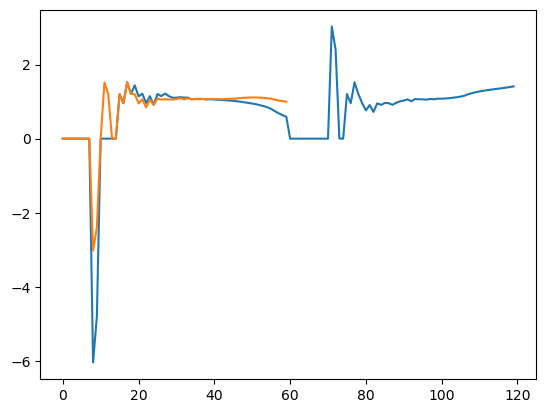

In [194]:
plt.plot(diff)
plt.plot(diff_central)

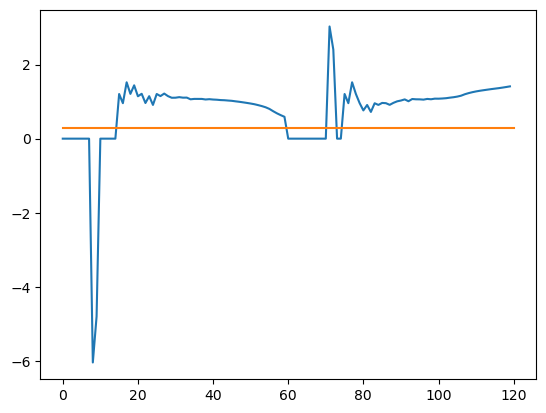

In [192]:
plt.plot(diff)
plt.plot(np.linspace(0, 120, 100), grad[0,0].tile(len(np.logspace(0, 120, 100))))

/var/folders/zz/9d0y_vp944zcnd6w_nl_3x6r0000gn/T/ipykernel_44720/4230748253.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.plot(torch.log10(torch.abs(step_sizes)), np.log10(diff))
/var/folders/zz/9d0y_vp944zcnd6w_nl_3x6r0000gn/T/ipykernel_44720/4230748253.py:1: RuntimeWarning: invalid value encountered in log10
  plt.plot(torch.log10(torch.abs(step_sizes)), np.log10(diff))
/var/folders/zz/9d0y_vp944zcnd6w_nl_3x6r0000gn/T/ipykernel_44720/4230748253.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(np.linspace(-7, -1, 100), np.log10(grad[0,0].tile(len(np.logspace(-7, -1, 100)))))


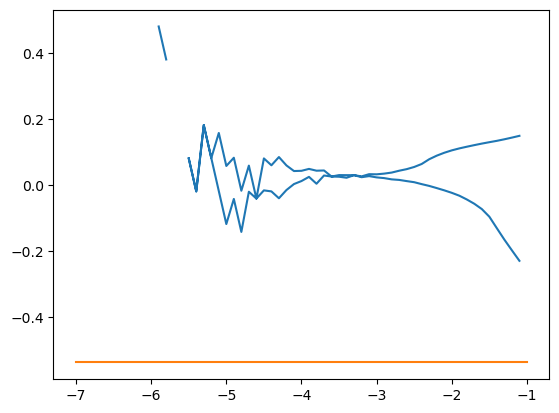

In [166]:
plt.plot(torch.log10(torch.abs(step_sizes)), np.log10(diff))
plt.plot(np.linspace(-7, -1, 100), np.log10(grad[0,0].tile(len(np.logspace(-7, -1, 100)))))

In [ ]:
grad_fd = torch.zeros(x_1.shape)


# step_sizes = float(10) ** (torch.arange(-8, -1, 1))
step = 1e-4
diff = []

for i in range(1):
    for j in range(x_1.shape[1]):
        x_1_perturb = x_1.clone().detach()
        x_1_perturb[i, j] += step
        _, log_p1_sample_perturb = solver.compute_likelihood(x_1=x_1_perturb,
                                method='midpoint',
                                step_size= 0.01,
                                log_p0= gaussian_log_density,
                                enable_grad = True, exact_divergence = True
                                )
        
        grad_fd[i,j] = ((log_p1_sample_perturb[i] - log_p1[i])/step)


In [ ]:
grad_fd = torch.zeros(x_1.shape)


# step_sizes = float(10) ** (torch.arange(-8, -1, 1))
step = 1e-4
diff = []

for i in range(1):
    for j in range(x_1.shape[1]):
        x_1_perturb = x_1.clone().detach()
        x_1_perturb[i, j] += step
        _, log_p1_sample_perturb = solver.compute_likelihood(x_1=x_1_perturb,
                                method='midpoint',
                                step_size= 0.01,
                                log_p0= gaussian_log_density,
                                enable_grad = True, exact_divergence = True
                                )
        
        grad_fd[i,j] = ((log_p1_sample_perturb[i] - log_p1[i])/step)


In [93]:
grad_fd

tensor([[ 1.9073, -0.6104,  1.0300,  ..., -0.3433,  6.2180,  7.8201],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
       grad_fn=<CopySlices>)

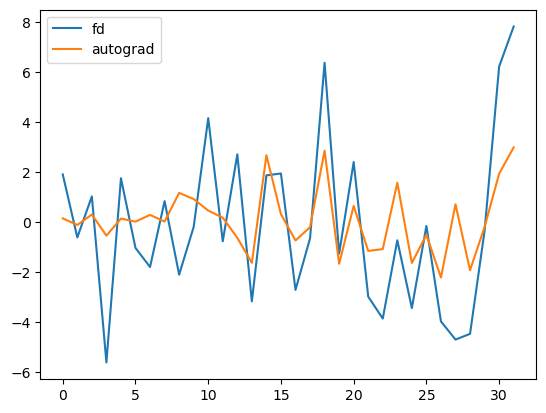

In [94]:
plt.plot(grad_fd.detach().numpy()[0, :], label = "fd")
plt.plot(grad.detach().numpy()[0, :], label = 'autograd')
plt.legend()

In [71]:
grad

tensor([[ 0.1504, -0.1122,  0.3068,  ..., -0.1947,  1.9375,  2.9877],
        [-0.8450, -1.0273,  1.3429,  ...,  0.1750, -0.5985,  2.1054],
        [-0.1492,  0.8729, -0.3537,  ..., -4.0530,  1.1765, -0.7787],
        ...,
        [-0.9029,  1.6693,  0.3819,  ..., -0.1972, -1.7688, -0.8446],
        [ 0.0879, -0.3978,  1.0979,  ...,  0.0191,  1.5529,  1.1534],
        [ 0.1877,  1.1977,  0.1475,  ...,  0.9007,  1.1485, -1.0625]])

In [ ]:
# from flow_matching.utils import gradient

# t = torch.tile(torch.arange(0, 1, 0.01)[np.newaxis, :], (300, 1))

# grad = torch.zeros(t.shape)

# with torch.set_grad_enabled(True):
#     y_init = (x_1, torch.zeros(x_1.shape[0], device=x_1.device))

#     xt = torch.tensor(y_init[0])
#     xt.requires_grad_()

#     for i in range(t.shape[1]):

#         t_step = t[:, i]
    
#         ut = velocity_model(xt, t_step)

#         for i in range(ut.flatten(1).shape[1]):
#             grad[:, i] = gradient(ut[:, i], xt, create_graph=True)[:, i]


In [ ]:
attenu_infer_reconstruct = attenu_pca.inverse_transform(x_1)
attenu_infer_reconstruct = attenu_infer_reconstruct.reshape((-1, int(np.sqrt(attenu_infer_reconstruct.shape[1])), int(np.sqrt(attenu_infer_reconstruct.shape[1]))))

prob_x_1 = torch.exp(log_p1)/torch.sum(log_p1)

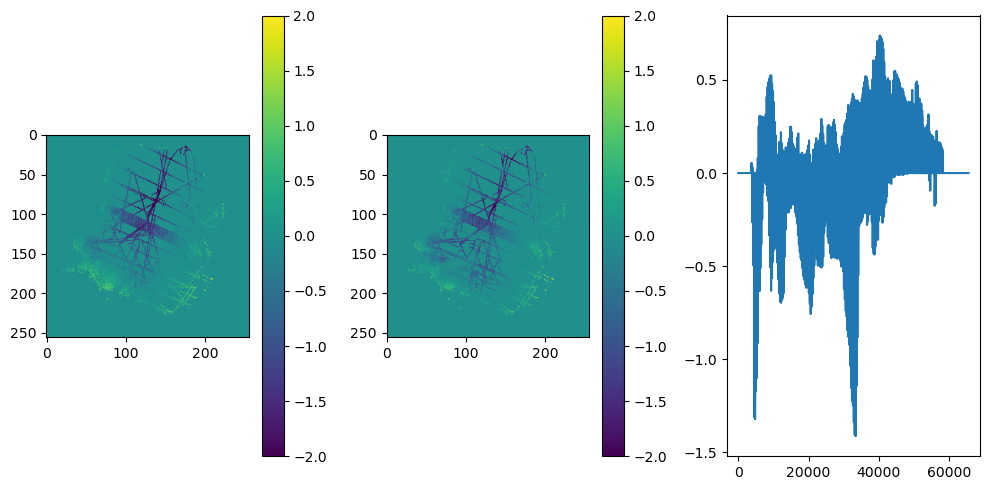

In [ ]:
fig, ax = plt.subplots(1,3, figsize = (10, 5))

idx_rand = np.random.choice(np.arange(0, np.shape(prob_x_1)[0]), size = 2, replace = False)

im0 = ax[0].imshow(attenu_infer_reconstruct[idx_rand[0], :, :], vmin = -2, vmax = 2)
plt.colorbar(im0)

im1 = ax[1].imshow(attenu_infer_reconstruct[idx_rand[1], :, :], vmin = -2, vmax = 2)
plt.colorbar(im1)

ax[2].plot((attenu_infer_reconstruct[idx_rand[0], :, :] - attenu_infer_reconstruct[idx_rand[1], :, :]).flatten())

fig.tight_layout()

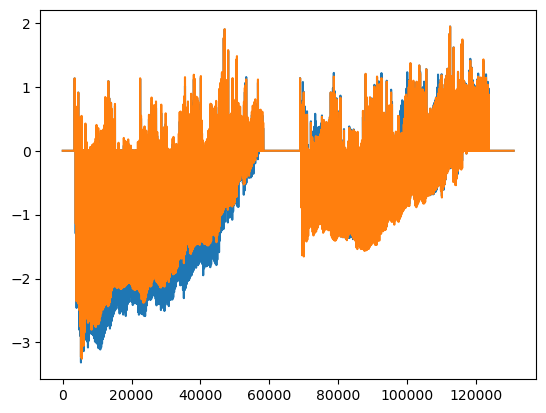

In [ ]:
percentiles = [2, 98]

attenu_fromEm_standard = np.load('../testing/attenu_fromEm_standard.npz')['attenu_fromEm_standard']
attenu_fromEm_standard = attenu_fromEm_standard[:, 0, :, :]

attenu_fromEm_standard_percentiles = np.percentile(attenu_fromEm_standard, percentiles, axis = 0)
attenu_infer_reconstruct_percentiles = np.percentile(attenu_infer_reconstruct, percentiles, axis = 0)

plt.plot(attenu_fromEm_standard_percentiles.flatten())
plt.plot(attenu_infer_reconstruct_percentiles.flatten())

In [ ]:
# from Autoencoder import Autoencoder

# image_dimension = 256
# batch_size = 4

# model = Autoencoder(image_dimension = image_dimension, batch_size = 4, kernel_1_size = 3, kernel_2_size = 5)
# model.load_state_dict(torch.load('autoencoder_2026-06-10 15:48:42.350148.pth', weights_only=True))

# x_1_decoded = model.decoder(x_1)

In [ ]:
p1_max = torch.max(torch.exp(log_p1)/torch.sum(torch.exp(log_p1)))
idx_max = torch.argmax(torch.exp(log_p1)/torch.sum(torch.exp(log_p1)))
p1_min = torch.min(torch.exp(log_p1)/torch.sum(torch.exp(log_p1)))
idx_min = torch.argmin(torch.exp(log_p1)/torch.sum(torch.exp(log_p1)))

In [ ]:
p1_max

tensor(0.1674)

In [ ]:
p1_min

tensor(2.7915e-16)

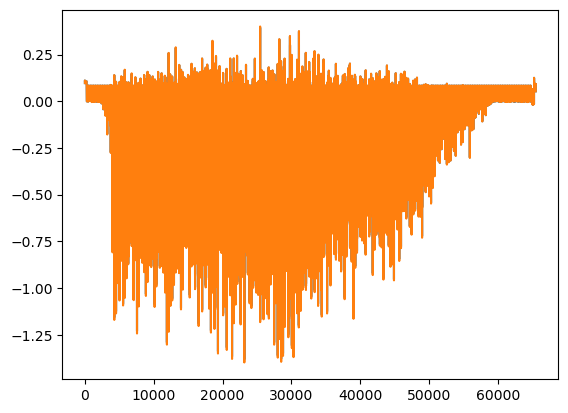

In [ ]:
im1 = plt.plot(x_1_decoded[0, 0, :, :].detach().numpy().flatten())
im1 = plt.plot(x_1_decoded[idx_min, 0, :, :].detach().numpy().flatten())

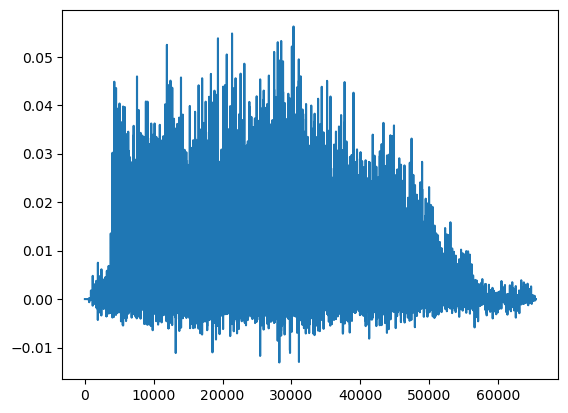

In [ ]:
im1 = plt.plot((x_1_decoded[idx_min, 0, :, :] - x_1_decoded[idx_max, 0, :, :]).detach().numpy().flatten())